In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [2]:
%load_ext autoreload
%autoreload 2 

#pour pas avoir à reload à chaque fois qu'on mofifie une fonction dans un autre fichier

Fonction preprocess pour 
- charger les données avec le nombre de n_rows et de features à définir
- split test et train
- % valeurs manquantes et drop lignes avec que des valeurs manquantes
- imputation 

In [24]:
from preprocess import preprocess_pipeline

mes_features = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g',
            'fiber_100g', 'proteins_100g', 'fruits-vegetables-legumes_100g',
            'fat_100g', 'carbohydrates_100g']

preprocess_9 = preprocess_pipeline(
    sample_size=10000,
    missing_threshold=50,
    features=mes_features
)

print(preprocess_9["X_train"].shape)
preprocess_9["X_train"].head()


(464, 7)


d:\Code_data\DESU_ROCHET\test\preprocess.py:26: DtypeWarning: Columns (0: abbreviated_product_name, 1: packaging_text, 2: no_nutrition_data) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_path, sep=sep, encoding=encoding, nrows=sample_size, quoting=csv.QUOTE_NONE)


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,carbohydrates_100g
8431,348.40,0.40,9.00,0.160,2.30,2.50,12.00
2158,563.70,2.40,7.00,0.508,2.20,5.90,17.60
3164,2450.00,25.00,26.00,0.010,10.00,45.00,31.00
8276,1506.20,0.10,0.50,1.000,8.70,0.50,74.20
1113,445.66,3.39,1.64,0.300,2.27,5.64,11.67


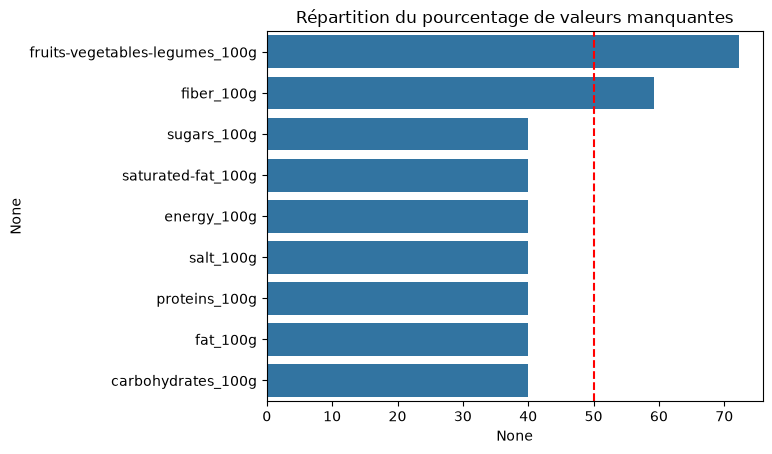

In [25]:
# affiche le graph du % des valeurs manquantes avec seuil 

percent_missing_9 = preprocess_9["percent_missing"]
filtered = percent_missing_9[percent_missing_9.values > 0]
ax = sns.barplot(x = filtered, y = filtered.index, orient='h');
ax.set_title(f"Répartition du pourcentage de valeurs manquantes");

threshold = 50

ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}") 



In [26]:
##vérifie qu'après "drop_rows_all_missing" on a des Nan ou pas à imputer.
## résultat = 1 valeur manquante dans saturated-fat et dans sugars 

from preprocess import load_data, split_known_unknown, split_train_test, compute_missing_percentage, get_columns_to_drop, apply_column_drop, drop_rows_all_missing

df = load_data(sample_size=10000)
df_connu, df_inconnu = split_known_unknown(df, target_col="nutriscore_grade")
X_train, X_test, y_train, y_test = split_train_test(df_connu, mes_features)

percent_missing = compute_missing_percentage(X_train)
columns_to_drop = get_columns_to_drop(percent_missing, threshold=50) 

X_train_avant_imputation = apply_column_drop(X_train, columns_to_drop)
X_train_avant_imputation = drop_rows_all_missing(X_train_avant_imputation)

print(X_train_avant_imputation.isna().sum())

energy_100g           0
saturated-fat_100g    1
sugars_100g           1
salt_100g             0
proteins_100g         0
fat_100g              0
carbohydrates_100g    0
dtype: int64


d:\Code_data\DESU_ROCHET\test\preprocess.py:26: DtypeWarning: Columns (0: abbreviated_product_name, 1: packaging_text, 2: no_nutrition_data) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_path, sep=sep, encoding=encoding, nrows=sample_size, quoting=csv.QUOTE_NONE)


In [ ]:
# Comparer avant/après imputation pour voir si les valeurs imputées sont cohérentes avec le reste de la colonne.

X_train_imputed = preprocess_9["X_train"]
features_restantes = list(X_train_imputed.columns)  # colonnes qui ont survécu au drop

def compare_dist(feature, raw_df, imputed_df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))

    # Bins communs calculés sur la plage combinée des deux distributions
    combined_min = min(raw_df[feature].min(), imputed_df[feature].min())
    combined_max = max(raw_df[feature].max(), imputed_df[feature].max())
    bins = np.linspace(combined_min, combined_max, 30)

    ax = axes[0]
    sns.histplot(raw_df.loc[:, feature], kde=True, ax=ax, bins=bins)
    ax.set_title(f"Raw {feature}")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax = axes[1]
    sns.histplot(imputed_df.loc[:, feature], kde=True, ax=ax, bins=bins)
    ax.set_title(f"Imputed {feature}")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

for feature in features_restantes:
    compare_dist(feature, X_train_avant_imputation, X_train_imputed)


Même pipeline mais sur TOUT le fichier (pas juste sample_size lignes), lu par morceaux (chunksize) pour ne pas tout charger en mémoire d'un coup (prend 8mn sur mon ordi(juliette))

In [ ]:
from preprocess import preprocess_pipeline

mes_features = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g',
            'fiber_100g', 'proteins_100g', 'fruits-vegetables-legumes_100g',
            'fat_100g', 'carbohydrates_100g']

preprocess_full = preprocess_pipeline(
    file_path=r"..\data\en.openfoodfacts.org.products.csv.gz",
    chunksize=100_000,   # lit le csv 100 000 lignes à la fois au lieu de tout d'un coup
    missing_threshold=50,
    features=mes_features
)

print(preprocess_full["X_train"].shape)
preprocess_full["X_train"].head()

In [ ]:
percent_missing_full = preprocess_full["percent_missing"]
filtered = percent_missing_full[percent_missing_full.values > 0]
ax = sns.barplot(x = filtered, y = filtered.index, orient='h');
ax.set_title(f"Répartition du pourcentage de valeurs manquantes");

threshold = 50

ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")